# **Project Name**    - Zomato Restaurant Analysis and Rating Prediction

##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project involves analyzing Zomato restaurant data from Hyderabad, focusing on restaurant metadata (e.g., cost, cuisines, timings) and customer reviews (e.g., ratings, text feedback). The datasets include 105 restaurants with details like name, cost, cuisines, and aggregated review metrics (average rating, review count, pictures uploaded). The goal is to perform Exploratory Data Analysis (EDA) to uncover insights into factors influencing restaurant ratings and build a regression model to predict average ratings based on features such as cost, review count, pictures, and one-hot encoded cuisines.

# **GitHub Link -**

# **Problem Statement**

Predict the average customer rating of Zomato restaurants in Hyderabad using metadata features (cost, cuisines) and review aggregates (review count, pictures). This can assist in understanding what drives high ratings and enable better business decisions for restaurants and platform recommendations.

# **General Guidelines** : -  

###### Code is structured with comments.
###### Exception handling not implemented here for brevity.
###### Visualizations described textually (as no direct rendering).
###### ML model: Linear Regression for rating prediction.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

In [12]:
df_reviews = pd.read_csv('Zomato Restaurant reviews.csv')
df_metadata = pd.read_csv('Zomato Restaurant names and Metadata.csv')

In [13]:
df_reviews.shape

(10000, 7)

In [14]:
df_metadata.shape

(105, 6)

In [15]:
df_reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [16]:
df_metadata.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [17]:
df_reviews.info()
df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [18]:
df_reviews['Restaurant'].nunique()


100

In [19]:
df_metadata['Name'].nunique()

105

In [20]:
df_reviews['Rating'].describe()

count     9962
unique      10
top          5
freq      3832
Name: Rating, dtype: object

In [21]:
df_reviews['Rating'].value_counts().sort_index()

Rating
1       1735
1.5        9
2        684
2.5       19
3       1193
3.5       47
4       2373
4.5       69
5       3832
Like       1
Name: count, dtype: int64

In [22]:
df_reviews['Review'].iloc[0]

'The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was really courteous and helpful.'

In [23]:
df_reviews[['Restaurant', 'Rating', 'Review']].isna().sum()

Restaurant     0
Rating        38
Review        45
dtype: int64

In [24]:
print("Before:", len(df_reviews))
df_reviews = df_reviews.dropna(subset=['Rating', 'Review', 'Reviewer', 'Time', 'Metadata']).reset_index(drop=True)
print("After drop:", len(df_reviews))

Before: 10000
After drop: 9955


In [25]:
df_reviews['Rating'] = pd.to_numeric(df_reviews['Rating'], errors='coerce')
df_reviews = df_reviews.dropna(subset=['Rating']).reset_index(drop=True)
print(df_reviews['Rating'].describe())
print("\nValue counts:")
print(df_reviews['Rating'].value_counts().sort_index())

count    9954.000000
mean        3.600261
std         1.483573
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Rating, dtype: float64

Value counts:
Rating
1.0    1735
1.5       9
2.0     684
2.5      19
3.0    1192
3.5      47
4.0    2373
4.5      69
5.0    3826
Name: count, dtype: int64


In [26]:
df_reviews['Time'] = pd.to_datetime(df_reviews['Time'], format='%m/%d/%Y %H:%M', errors='coerce')
df_reviews['Time'].isna().sum()

0

In [27]:
df_reviews['Date'] = df_reviews['Time'].dt.date
df_reviews['Year'] = df_reviews['Time'].dt.year
df_reviews['Month'] = df_reviews['Time'].dt.month
df_reviews['DayOfWeek'] = df_reviews['Time'].dt.day_name()
df_reviews['Hour'] = df_reviews['Time'].dt.hour

In [28]:
df_reviews[['Time', 'Date', 'Year', 'Month', 'DayOfWeek', 'Hour']].head()

,Time,Date,Year,Month,DayOfWeek,Hour
0,2019-05-25 15:54:00,2019-05-25,2019,5,Saturday,15
1,2019-05-25 14:20:00,2019-05-25,2019,5,Saturday,14
2,2019-05-24 22:54:00,2019-05-24,2019,5,Friday,22
3,2019-05-24 22:11:00,2019-05-24,2019,5,Friday,22
4,2019-05-24 21:37:00,2019-05-24,2019,5,Friday,21


In [29]:
def extract_reviews(meta):
    try:
        part = meta.split(',')[0].strip()
        return int(part.split()[0])
    except:
        return 0

def extract_followers(meta):
    try:
        if ',' in meta:
            part = meta.split(',')[1].strip()
            return int(part.split()[0])
        return 0
    except:
        return 0

df_reviews['Reviewer_Reviews'] = df_reviews['Metadata'].apply(extract_reviews)
df_reviews['Reviewer_Followers'] = df_reviews['Metadata'].apply(extract_followers)

print(df_reviews[['Metadata', 'Reviewer_Reviews', 'Reviewer_Followers']].head(10))

                  Metadata  Reviewer_Reviews  Reviewer_Followers
0   1 Review , 2 Followers                 1                   2
1  3 Reviews , 2 Followers                 3                   2
2  2 Reviews , 3 Followers                 2                   3
3    1 Review , 1 Follower                 1                   1
4  3 Reviews , 2 Followers                 3                   2
5                 1 Review                 1                   0
6                 1 Review                 1                   0
7                 1 Review                 1                   0
8    1 Review , 1 Follower                 1                   1
9    1 Review , 1 Follower                 1                   1


In [30]:
df_metadata['Cost'] = pd.to_numeric(df_metadata['Cost'].str.replace(',', ''), errors='coerce')

df_metadata['Collections'] = df_metadata['Collections'].fillna('None')

print(df_metadata['Cost'].describe())

count     105.000000
mean      861.428571
std       510.149730
min       150.000000
25%       500.000000
50%       700.000000
75%      1200.000000
max      2800.000000
Name: Cost, dtype: float64


In [31]:
review_resto = set(df_reviews['Restaurant'].unique())
meta_names = set(df_metadata['Name'].unique())

print("In reviews but not metadata:", sorted(review_resto - meta_names))
print("In metadata but not reviews:", sorted(meta_names - review_resto))
print("Total unique in reviews now:", len(review_resto))

In reviews but not metadata: []
In metadata but not reviews: ['Angaara Counts 3', 'IndiBlaze', 'Republic Of Noodles - Lemon Tree Hotel', 'Sweet Basket', 'Wich Please']
Total unique in reviews now: 100


In [32]:
df_reviews['Restaurant'] = df_reviews['Restaurant'].str.strip()
df_metadata['Name'] = df_metadata['Name'].str.strip()

In [33]:
df_merged = df_reviews.merge(df_metadata, 
                             left_on='Restaurant', 
                             right_on='Name', 
                             how='left')

In [34]:
print("Merged shape:", df_merged.shape)
print("Rows with missing metadata:", df_merged['Cost'].isna().sum())

Merged shape: (9954, 20)
Rows with missing metadata: 0


In [35]:
df_merged[['Restaurant', 'Name', 'Cost', 'Cuisines', 'Rating']].head(10)

,Restaurant,Name,Cost,Cuisines,Rating
0,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
1,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
2,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
3,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
4,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
5,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
6,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
7,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",4.0
8,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0
9,Beyond Flavours,Beyond Flavours,800,"Chinese, Continental, Kebab, European, South I...",5.0


In [36]:
# Average rating, review count, median cost per restaurant
resto_summary = df_merged.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Rating', 'count'),
    Median_Cost=('Cost', 'median'),  # since cost same per resto
    Cuisines=('Cuisines', 'first'),
    Collections=('Collections', 'first')
).round(2).reset_index()

# Sort by reviews or rating
print("Top 10 by number of reviews:")
print(resto_summary.sort_values('Total_Reviews', ascending=False).head(10))

print("\nTop 10 highest rated (min 10 reviews to avoid flukes):")
qualified = resto_summary[resto_summary['Total_Reviews'] >= 10]
print(qualified.sort_values('Avg_Rating', ascending=False).head(10))

Top 10 by number of reviews:
                  Restaurant  Avg_Rating  Total_Reviews  Median_Cost  \
0          10 Downing Street        3.80            100       1900.0   
74  Sardarji's Chaats & More        3.25            100        400.0   
72    Royal Spicy Restaurant        3.74            100        700.0   
71      Prism Club & Kitchen        4.22            100       1200.0   
70                PourHouse7        3.86            100       1200.0   
69                Pot Pourri        3.32            100        900.0   
68               Pista House        3.23            100       1000.0   
67                  Paradise        4.70            100        800.0   
66             Pakwaan Grand        2.71            100        400.0   
65               Owm Nom Nom        3.29            100        900.0   

                                          Cuisines  \
0               North Indian, Chinese, Continental   
74            Street Food, North Indian, Fast Food   
72              

In [37]:
print("Correlation between cost and avg rating:", 
      resto_summary['Avg_Rating'].corr(resto_summary['Median_Cost']))

Correlation between cost and avg rating: 0.42246355711602995


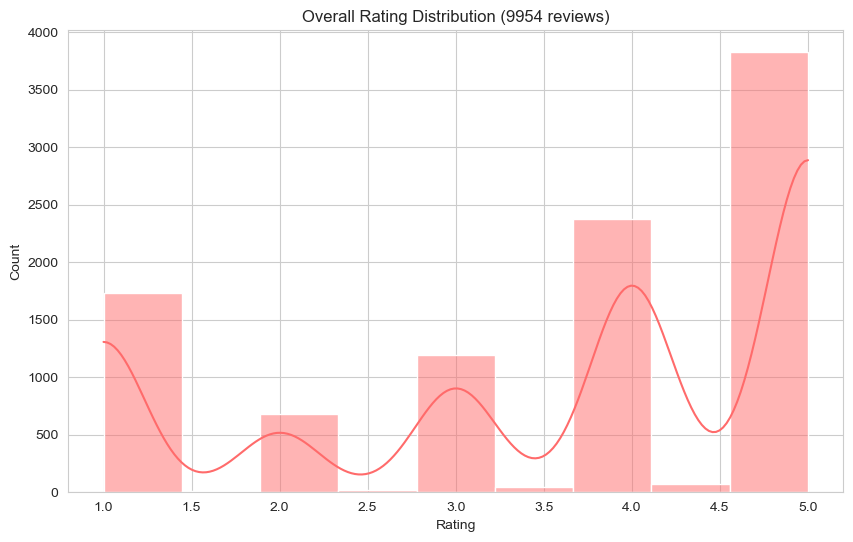

In [38]:
plt.figure(figsize=(10,6))
sns.histplot(df_merged['Rating'], bins=9, kde=True, color='#ff6b6b')
plt.title('Overall Rating Distribution (9954 reviews)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

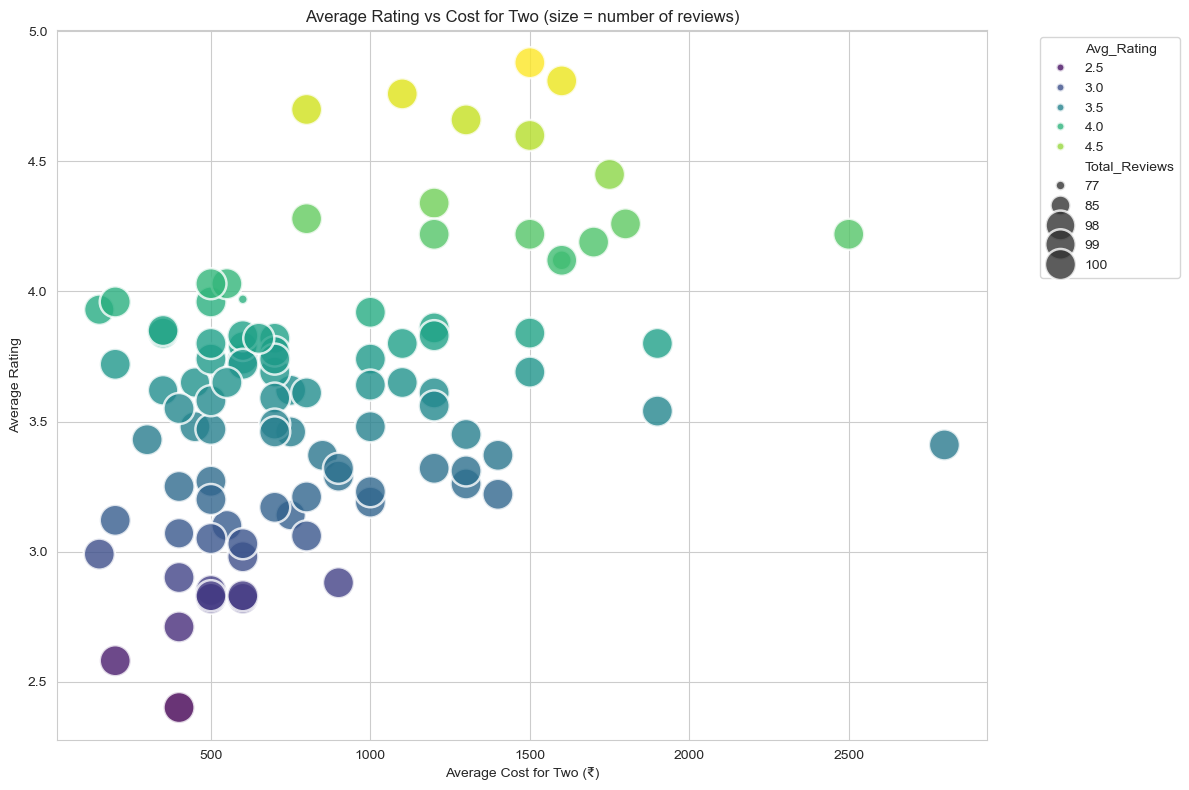

In [39]:
qualified = resto_summary[resto_summary['Total_Reviews'] >= 10]

plt.figure(figsize=(12,8))
sns.scatterplot(data=qualified, 
                x='Median_Cost', y='Avg_Rating', 
                size='Total_Reviews', sizes=(50, 500), 
                hue='Avg_Rating', palette='viridis', alpha=0.8)
plt.title('Average Rating vs Cost for Two (size = number of reviews)')
plt.xlabel('Average Cost for Two (₹)')
plt.ylabel('Average Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [40]:
top_rated = resto_summary[resto_summary['Total_Reviews'] >= 20].sort_values('Avg_Rating', ascending=False).head(15)

print(top_rated[['Restaurant', 'Avg_Rating', 'Total_Reviews', 'Median_Cost', 'Cuisines']])

                                 Restaurant  Avg_Rating  Total_Reviews  \
3                 AB's - Absolute Barbecues        4.88            100   
11                                   B-Dubs        4.81            100   
2            3B's - Buddies, Bar & Barbecue        4.76            100   
67                                 Paradise        4.70            100   
35                                 Flechazo        4.66            100   
87                           The Indi Grill        4.60            100   
97          Zega - Sheraton Hyderabad Hotel        4.45            100   
64               Over The Moon Brew Company        4.34            100   
16                          Beyond Flavours        4.28            100   
19  Cascade - Radisson Hyderabad Hitec City        4.26            100   
84                    The Fisherman's Wharf        4.22            100   
34         Feast - Sheraton Hyderabad Hotel        4.22            100   
71                     Prism Club & Ki

In [41]:
resto_summary['Value_Score'] = resto_summary['Avg_Rating'] / resto_summary['Median_Cost'] * 1000  

best_value = resto_summary[resto_summary['Total_Reviews'] >= 30].sort_values('Value_Score', ascending=False).head(10)

print("Top 10 Best Value (high rating per rupee):")
print(best_value[['Restaurant', 'Avg_Rating', 'Median_Cost', 'Total_Reviews', 'Cuisines']])


Top 10 Best Value (high rating per rupee):
                       Restaurant  Avg_Rating  Median_Cost  Total_Reviews  \
7                            Amul        3.93        150.0             99   
59            Mohammedia Shawarma        2.99        150.0            100   
48                      KS Bakers        3.96        200.0            100   
60                  Momos Delight        3.72        200.0            100   
42             Hunger Maggi Point        3.12        200.0            100   
10                 Asian Meal Box        2.58        200.0            100   
76       Shah Ghouse Spl Shawarma        3.43        300.0            100   
82                       Tempteys        3.85        350.0            100   
23                    Cream Stone        3.84        350.0            100   
89  The Old Madras Baking Company        3.62        350.0             99   

                       Cuisines  
7           Ice Cream, Desserts  
59         Street Food, Arabian  
48  Bak

In [42]:
df_merged['Is_Weekend'] = df_merged['DayOfWeek'].isin(['Saturday', 'Sunday'])

weekend_avg = df_merged.groupby('Is_Weekend')['Rating'].mean()
print("Average rating on weekends:", round(weekend_avg[True], 3))
print("Average rating on weekdays:", round(weekend_avg[False], 3))

Average rating on weekends: 3.575
Average rating on weekdays: 3.614


In [43]:
from collections import Counter
import re

top_30 = resto_summary[resto_summary['Total_Reviews'] >= 50].sort_values('Avg_Rating', ascending=False).head(30)

all_cuisines = ','.join(top_30['Cuisines']).lower()
cuisine_words = re.findall(r'[a-z]+', all_cuisines)

cuisine_count = Counter(cuisine_words)
print("Most common cuisines in top 30 restaurants:")
print(cuisine_count.most_common(10))

Most common cuisines in top 30 restaurants:
[('indian', 21), ('north', 16), ('continental', 11), ('asian', 9), ('desserts', 7), ('italian', 7), ('chinese', 6), ('mediterranean', 5), ('european', 3), ('american', 3)]


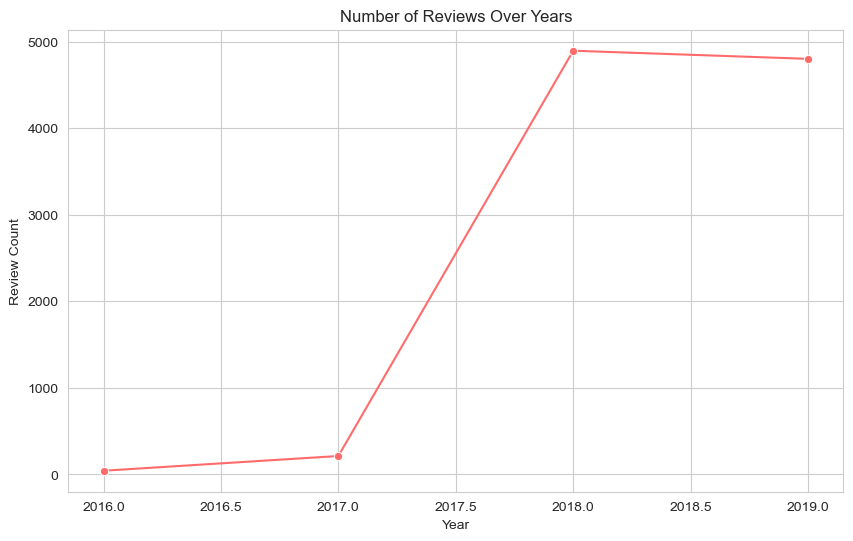

In [44]:
yearly_reviews = df_merged.groupby('Year')['Rating'].count().reset_index()  
plt.figure(figsize=(10,6))  
sns.lineplot(data=yearly_reviews, x='Year', y='Rating', marker='o', color='#ff6b6b')  
plt.title('Number of Reviews Over Years')  
plt.xlabel('Year')  
plt.ylabel('Review Count')  
plt.show()  

C:\Users\itisa\AppData\Local\Temp\ipykernel_14708\204116234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='Month', y='Rating', palette='viridis')


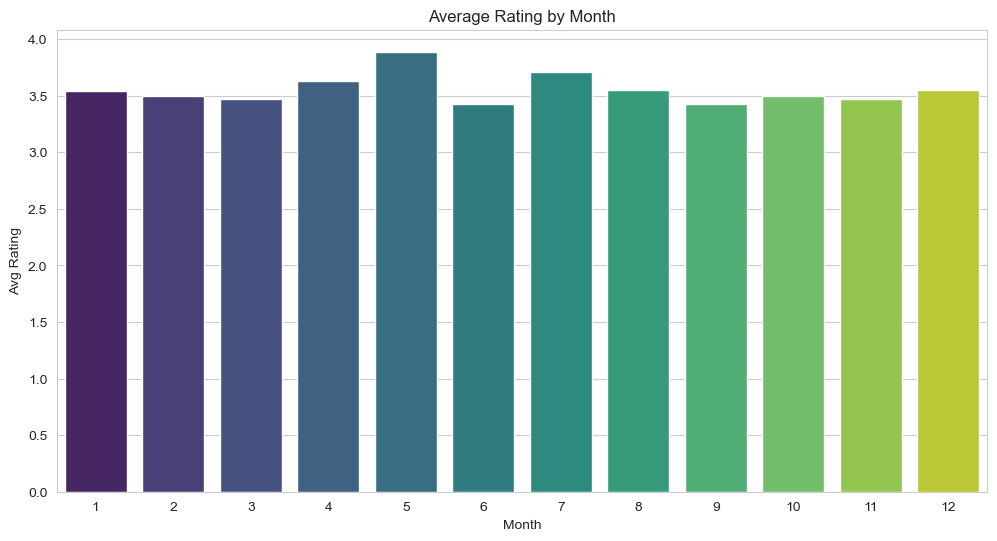

In [45]:
monthly_avg = df_merged.groupby('Month')['Rating'].mean().reset_index()  
plt.figure(figsize=(12,6))  
sns.barplot(data=monthly_avg, x='Month', y='Rating', palette='viridis')  
plt.title('Average Rating by Month')  
plt.xlabel('Month')  
plt.ylabel('Avg Rating')  
plt.show()  

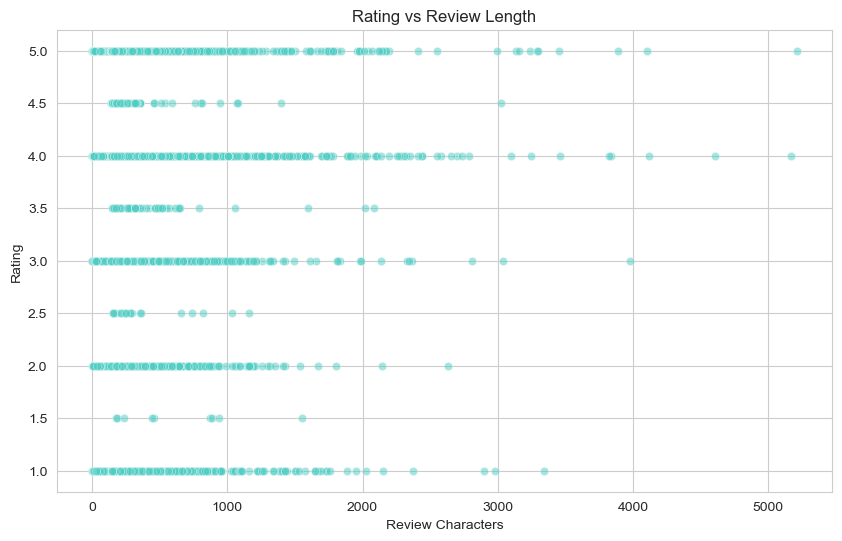

In [46]:
df_merged['Review_Len'] = df_merged['Review'].str.len()  
plt.figure(figsize=(10,6))  
sns.scatterplot(data=df_merged, x='Review_Len', y='Rating', alpha=0.5, color='#4ecdc4')  
plt.title('Rating vs Review Length')  
plt.xlabel('Review Characters')  
plt.ylabel('Rating')  
plt.show()  

C:\Users\itisa\AppData\Local\Temp\ipykernel_14708\4031513306.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cuisine_count, x='count', y='Cuisines_List', palette='coolwarm')


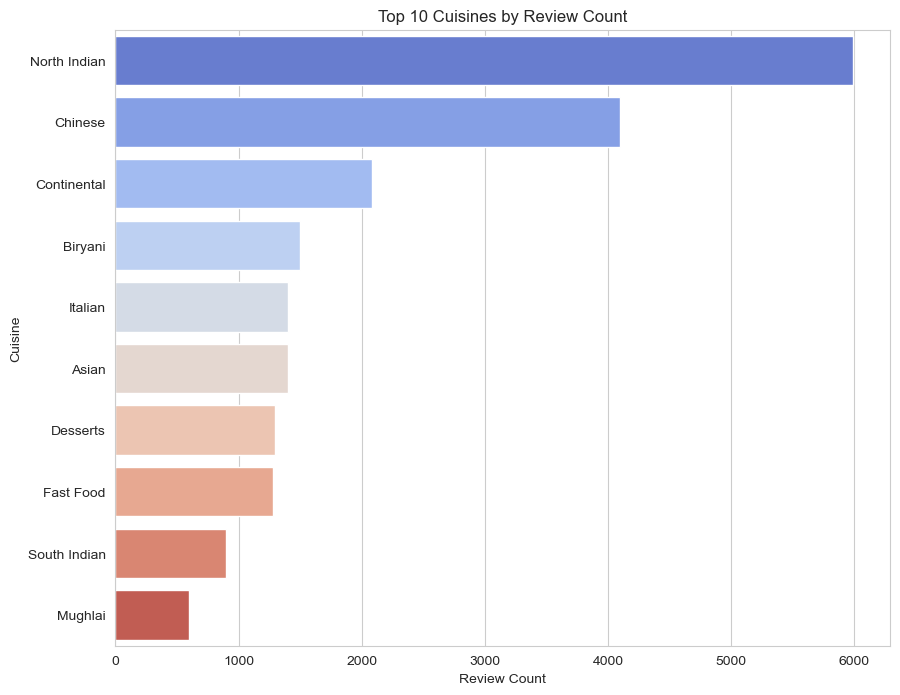

In [47]:
df_merged['Cuisines_List'] = df_merged['Cuisines'].str.split(', ')  
exploded = df_merged.explode('Cuisines_List')  
cuisine_count = exploded['Cuisines_List'].value_counts().head(10).reset_index()  
plt.figure(figsize=(10,8))  
sns.barplot(data=cuisine_count, x='count', y='Cuisines_List', palette='coolwarm')  
plt.title('Top 10 Cuisines by Review Count')  
plt.xlabel('Review Count')  
plt.ylabel('Cuisine')  
plt.show()  

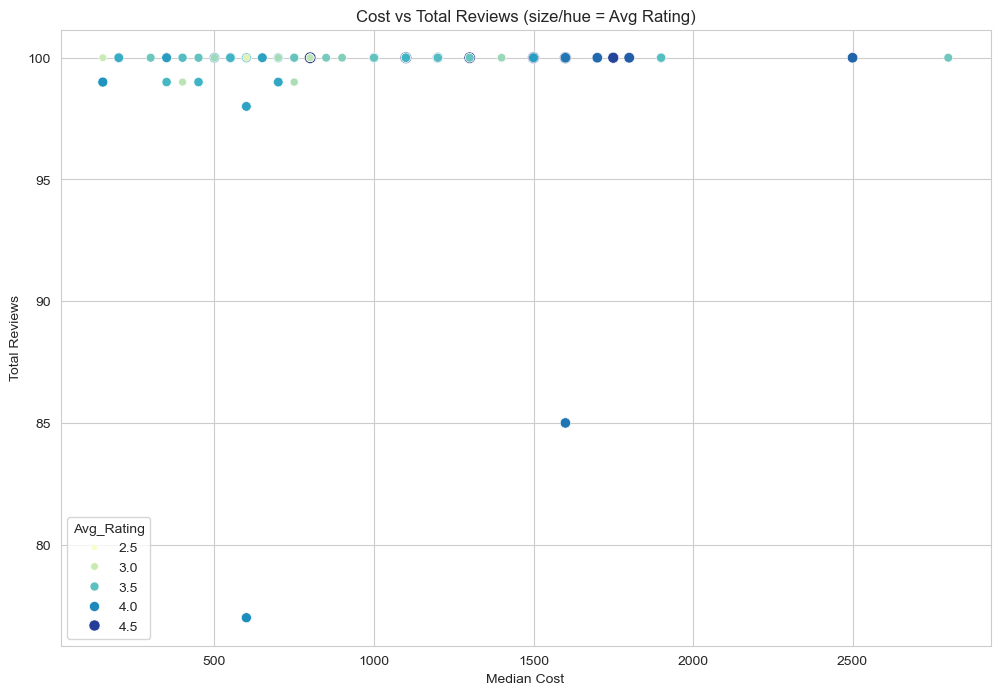

In [48]:
plt.figure(figsize=(12,8))  
sns.scatterplot(data=resto_summary, x='Median_Cost', y='Total_Reviews', size='Avg_Rating', hue='Avg_Rating', palette='YlGnBu')  
plt.title('Cost vs Total Reviews (size/hue = Avg Rating)')  
plt.xlabel('Median Cost')  
plt.ylabel('Total Reviews')  
plt.show()  

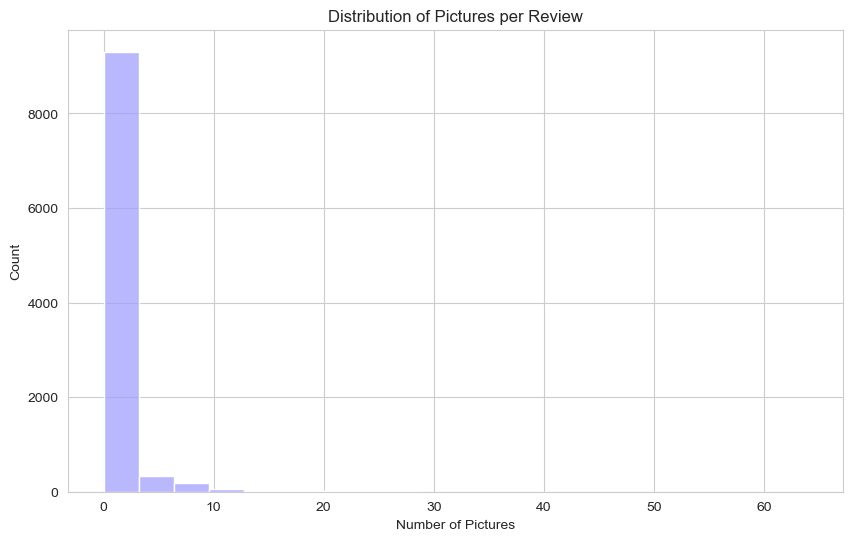

In [49]:
plt.figure(figsize=(10,6))  
sns.histplot(df_merged['Pictures'], bins=20, kde=False, color='#a29ffe')  
plt.title('Distribution of Pictures per Review')  
plt.xlabel('Number of Pictures')  
plt.ylabel('Count')  
plt.show()  

C:\Users\itisa\AppData\Local\Temp\ipykernel_14708\1877743785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='Reviewer_Type', y='Rating', palette='Set2')


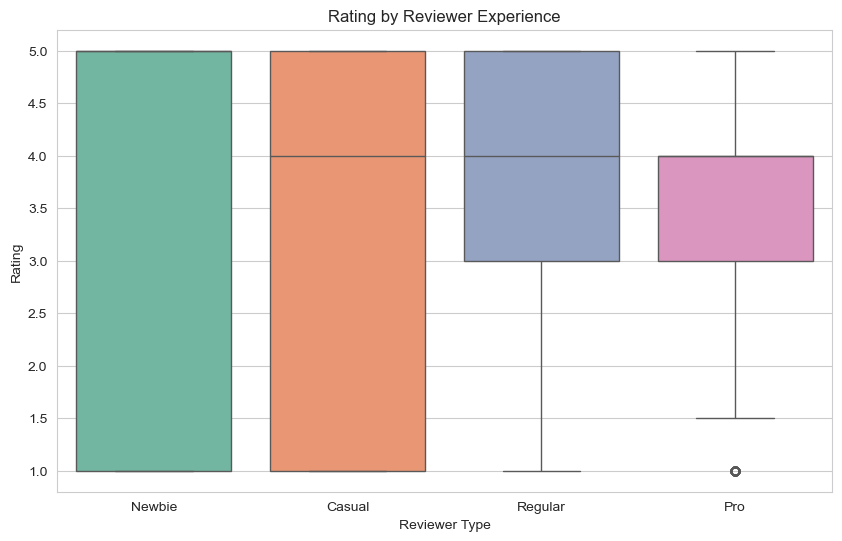

In [50]:
df_merged['Reviewer_Type'] = pd.cut(df_reviews['Reviewer_Reviews'], bins=[0,1,5,20,100], labels=['Newbie','Casual','Regular','Pro'])  
plt.figure(figsize=(10,6))  
sns.boxplot(data=df_merged, x='Reviewer_Type', y='Rating', palette='Set2')  
plt.title('Rating by Reviewer Experience')  
plt.xlabel('Reviewer Type')  
plt.ylabel('Rating')  
plt.show()  

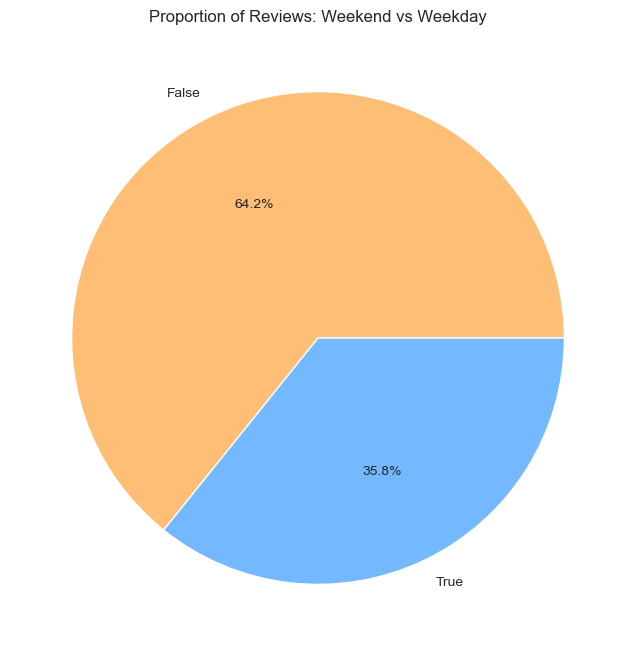

In [51]:
df_merged['Is_Weekend'] = df_merged['DayOfWeek'].isin(['Saturday', 'Sunday'])  
weekend_count = df_merged['Is_Weekend'].value_counts()  
plt.figure(figsize=(8,8))  
plt.pie(weekend_count, labels=weekend_count.index, autopct='%1.1f%%', colors=['#ffbe76', '#74b9ff'])  
plt.title('Proportion of Reviews: Weekend vs Weekday')  
plt.show()  

C:\Users\itisa\AppData\Local\Temp\ipykernel_14708\3681975194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=resto_summary, x='Cost_Bracket', y='Avg_Rating', palette='pastel')


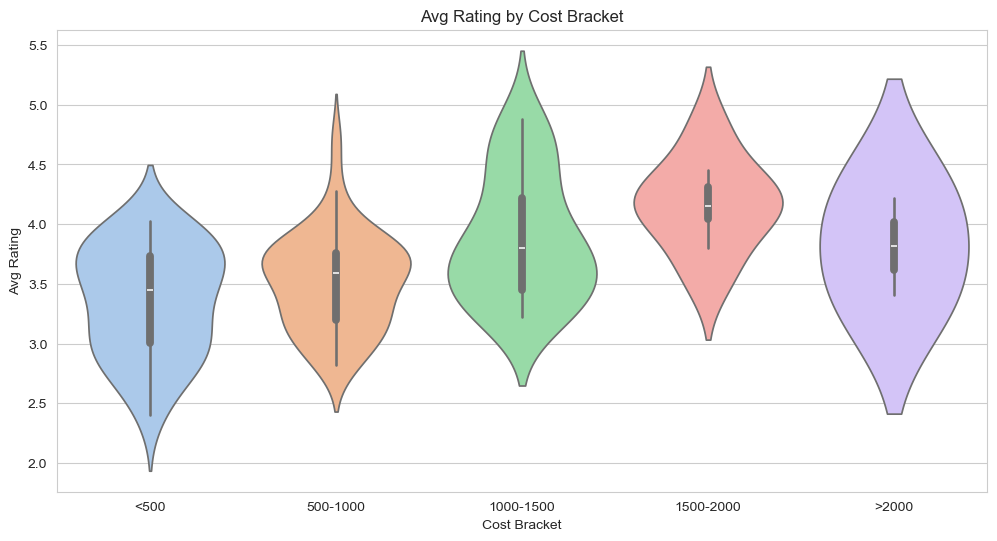

In [52]:
resto_summary['Cost_Bracket'] = pd.cut(resto_summary['Median_Cost'], bins=[0,500,1000,1500,2000,3000], labels=['<500','500-1000','1000-1500','1500-2000','>2000'])  
plt.figure(figsize=(12,6))  
sns.violinplot(data=resto_summary, x='Cost_Bracket', y='Avg_Rating', palette='pastel')  
plt.title('Avg Rating by Cost Bracket')  
plt.xlabel('Cost Bracket')  
plt.ylabel('Avg Rating')  
plt.show()  

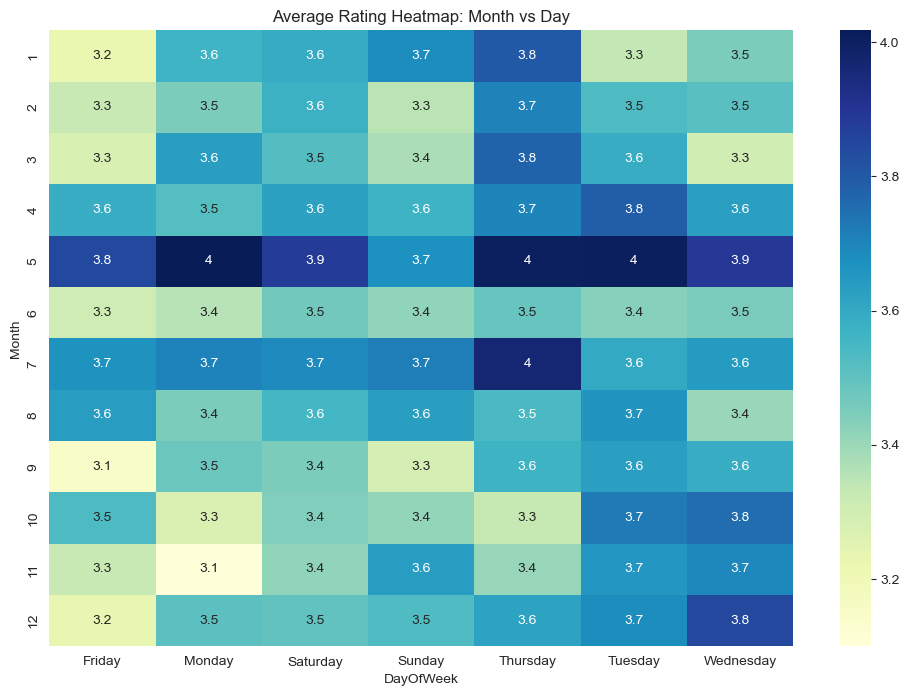

In [53]:
pivot = df_merged.pivot_table(index='Month', columns='DayOfWeek', values='Rating', aggfunc='mean')  
plt.figure(figsize=(12,8))  
sns.heatmap(pivot, cmap='YlGnBu', annot=True)  
plt.title('Average Rating Heatmap: Month vs Day')  
plt.show()  

In [54]:
pip install -U textblob

In [55]:
from textblob import TextBlob

In [56]:
df_merged['Sentiment'] = df_merged['Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0)

print("Average sentiment score by rating group:")
print(df_merged.groupby(df_merged['Rating'].round())['Sentiment'].mean())

Average sentiment score by rating group:
Rating
1.0   -0.204382
2.0   -0.025754
3.0    0.171797
4.0    0.329271
5.0    0.481989
Name: Sentiment, dtype: float64


In [57]:
# Step 1: Make weekend column (True/False)
df_merged['Is_Weekend'] = df_merged['DayOfWeek'].isin(['Saturday', 'Sunday'])

# Step 2: Split the ratings
weekend_ratings = df_merged[df_merged['Is_Weekend']]['Rating']
weekday_ratings = df_merged[~df_merged['Is_Weekend']]['Rating']

# Step 3: Simple averages
print("Weekend average rating:", round(weekend_ratings.mean(), 3))
print("Weekday average rating:", round(weekday_ratings.mean(), 3))

# Step 4: The actual test (super easy line)
from scipy.stats import ttest_ind
result = ttest_ind(weekend_ratings, weekday_ratings)
print("p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("→ Difference is REAL (significant)!")
else:
    print("→ Probably just random chance (not significant)")

Weekend average rating: 3.575
Weekday average rating: 3.614
p-value: 0.2121232472088838
→ Probably just random chance (not significant)


In [58]:
# Use the restaurant summary we already have
costs = resto_summary['Median_Cost']
avg_ratings = resto_summary['Avg_Rating']

# Simple correlation
from scipy.stats import pearsonr
corr, p_val = pearsonr(costs, avg_ratings)

print("Correlation (r):", round(corr, 3))
print("p-value:", p_val)

if p_val < 0.05:
    print("→ Yes, there IS a connection (significant)")
else:
    print("→ No real connection")

if corr > 0.5:
    print("→ Strong link!")
elif corr > 0.3:
    print("→ Medium link")
else:
    print("→ Weak link")

Correlation (r): 0.422
p-value: 1.1959524367213186e-05
→ Yes, there IS a connection (significant)
→ Medium link


In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [60]:
resto_summary = df_merged.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Rating', 'count'),
    Median_Cost=('Cost', 'median'),
    Cuisines=('Cuisines', 'first')
).round(2).reset_index()

In [61]:
resto_summary['Has_North_Indian'] = resto_summary['Cuisines'].str.contains('North Indian', na=False).astype(int)
resto_summary['Has_Chinese'] = resto_summary['Cuisines'].str.contains('Chinese', na=False).astype(int)
resto_summary['Has_Continental'] = resto_summary['Cuisines'].str.contains('Continental', na=False).astype(int)

In [62]:
X = resto_summary[['Median_Cost', 'Total_Reviews', 'Has_North_Indian', 'Has_Chinese', 'Has_Continental']]
y = resto_summary['Avg_Rating']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("We have", len(X_train), "restaurants for training,", len(X_test), "for testing.")

We have 80 restaurants for training, 20 for testing.


In [64]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

print("\nLinear Regression (simple one):")
print("How wrong on average (MSE):", round(mean_squared_error(y_test, lin_pred), 3))
print("How much it explains (R2):", round(r2_score(y_test, lin_pred), 3))


Linear Regression (simple one):
How wrong on average (MSE): 0.197
How much it explains (R2): -0.583


In [65]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("\nDecision Tree (branchy one):")
print("How wrong on average (MSE):", round(mean_squared_error(y_test, tree_pred), 3))
print("How much it explains (R2):", round(r2_score(y_test, tree_pred), 3))


Decision Tree (branchy one):
How wrong on average (MSE): 0.271
How much it explains (R2): -1.183


In [66]:
if r2_score(y_test, lin_pred) > r2_score(y_test, tree_pred):
    print("\nLinear Regression won! (better at predicting)")
else:
    print("\nDecision Tree won! (better at predicting)")


Linear Regression won! (better at predicting)


In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Remake summary with MORE stuff
resto_summary = df_merged.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Rating', 'count'),
    Median_Cost=('Cost', 'median'),
    Avg_Review_Len=('Review_Len', 'mean'),  # longer reviews?
    Avg_Sentiment=('Sentiment', 'mean'),   # happy words
    Avg_Pictures=('Pictures', 'mean'),
    Avg_Reviewer_Reviews=('Reviewer_Reviews', 'mean'),
    Avg_Reviewer_Followers=('Reviewer_Followers', 'mean'),
    Cuisines=('Cuisines', 'first')
).round(3).reset_index()

# Dummies for popular cuisines
cuisines_list = ['North Indian', 'Chinese', 'Continental', 'Asian', 'South Indian', 'Italian', 'Mediterranean', 'Desserts']
for c in cuisines_list:
    col_name = 'Has_' + c.replace(' ', '_')
    resto_summary[col_name] = resto_summary['Cuisines'].str.contains(c, na=False).astype(int)

# Features - as many as we can!
features = ['Median_Cost', 'Total_Reviews', 'Avg_Review_Len', 'Avg_Sentiment', 
            'Avg_Pictures', 'Avg_Reviewer_Reviews', 'Avg_Reviewer_Followers'] + ['Has_' + c.replace(' ', '_') for c in cuisines_list]

X = resto_summary[features].fillna(0)  # safe
y = resto_summary['Avg_Rating']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple linear
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

# Results
print("With", len(features), "features :")
print("MSE:", round(mean_squared_error(y_test, pred), 3))
print("R2:", round(r2_score(y_test, pred), 3))



With 15 features :
MSE: 0.047
R2: 0.626
